In [2]:
# ============================================================
# MULTI-PRODUCT FORECASTING PIPELINE
# Batch Forecasting Across All Products
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path  # <-- This was missing!
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 8)

print("="*70)
print("MULTI-PRODUCT FORECASTING PIPELINE")
print("Scaling Advanced Models to All Products")
print("="*70)
print("\n✓ Libraries loaded successfully")

MULTI-PRODUCT FORECASTING PIPELINE
Scaling Advanced Models to All Products

✓ Libraries loaded successfully


In [3]:
# ============================================================
# LOAD DATA - ALL PRODUCTS
# ============================================================

# Load processed data with features
data_path = Path("../../data/processed/sample_with_features.parquet")
df = pd.read_parquet(data_path)

print(f"Dataset loaded: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

# Get all unique products
all_products = df['id'].unique()
print(f"\nTotal products: {len(all_products)}")
print(f"Products: {all_products[:5]}... (showing first 5)")

# Create train/test split (last 28 days for test)
test_days = 28
product_splits = {}

for product_id in all_products:
    product_data = df[df['id'] == product_id].sort_values('date').reset_index(drop=True)
    
    train = product_data[:-test_days].copy()
    test = product_data[-test_days:].copy()
    
    product_splits[product_id] = {
        'train': train,
        'test': test,
        'y_train': train['sales'].values,
        'y_test': test['sales'].values
    }

print(f"\n✓ Data split for {len(product_splits)} products")
print(f"Train days per product: ~{len(product_splits[all_products[0]]['train'])}")
print(f"Test days per product: {len(product_splits[all_products[0]]['test'])}")


Dataset loaded: (18850, 61)
Date range: 2011-01-29 00:00:00 to 2016-03-27 00:00:00

Total products: 10
Products: ['FOODS_1_049_TX_2_validation' 'FOODS_1_079_CA_4_validation'
 'FOODS_1_097_CA_2_validation' 'FOODS_2_052_WI_1_validation'
 'FOODS_2_078_CA_4_validation']... (showing first 5)

✓ Data split for 10 products
Train days per product: ~1857
Test days per product: 28


In [4]:
# ============================================================
# BATCH FORECASTING FUNCTIONS
# ============================================================

def forecast_arima(y_train, horizon, order=(1,0,1)):
    """Train ARIMA and forecast."""
    try:
        model = ARIMA(y_train, order=order)
        fitted = model.fit()
        forecast = fitted.forecast(steps=horizon)
        return forecast
    except:
        # Fallback to mean if ARIMA fails
        return np.full(horizon, y_train.mean())

def forecast_prophet(train_data, test_data):
    """Train Prophet and forecast."""
    try:
        # Prepare data for Prophet
        prophet_train = pd.DataFrame({
            'ds': train_data['date'].values,
            'y': train_data['sales'].values
        })
        
        prophet_future = pd.DataFrame({
            'ds': test_data['date'].values
        })
        
        # Train model
        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False,
            seasonality_mode='additive'
        )
        model.fit(prophet_train)
        
        # Forecast
        forecast = model.predict(prophet_future)
        return forecast['yhat'].values
    except:
        # Fallback to mean
        return np.full(len(test_data), train_data['sales'].mean())

def forecast_ma(y_train, horizon, window=7):
    """Simple moving average forecast."""
    ma_value = np.mean(y_train[-window:])
    return np.full(horizon, ma_value)

def calculate_metrics(y_true, y_pred):
    """Calculate forecasting metrics."""
    y_pred_clipped = np.maximum(y_pred, 0)  # No negative forecasts
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred_clipped))
    mae = mean_absolute_error(y_true, y_pred_clipped)
    mape = np.mean(np.abs((y_true - y_pred_clipped) / (y_true + 1e-10))) * 100
    
    return {'rmse': rmse, 'mae': mae, 'mape': mape}

print("✓ Forecasting functions defined")

✓ Forecasting functions defined


In [5]:
# ============================================================
# RUN BATCH FORECASTING - ALL PRODUCTS
# ============================================================

print("="*70)
print("FORECASTING ALL PRODUCTS")
print("="*70)

results = []

for i, product_id in enumerate(all_products, 1):
    print(f"\nProduct {i}/{len(all_products)}: {product_id}")
    
    # Get data
    data = product_splits[product_id]
    train_df = data['train']
    test_df = data['test']
    y_train = data['y_train']
    y_test = data['y_test']
    
    # Forecast with each model
    print("  Running models...", end=" ")
    
    # ARIMA
    arima_pred = forecast_arima(y_train, len(y_test))
    arima_metrics = calculate_metrics(y_test, arima_pred)
    
    # Prophet
    prophet_pred = forecast_prophet(train_df, test_df)
    prophet_metrics = calculate_metrics(y_test, prophet_pred)
    
    # MA-7
    ma7_pred = forecast_ma(y_train, len(y_test), window=7)
    ma7_metrics = calculate_metrics(y_test, ma7_pred)
    
    # MA-28
    ma28_pred = forecast_ma(y_train, len(y_test), window=28)
    ma28_metrics = calculate_metrics(y_test, ma28_pred)
    
    print("✓")
    
    # Store results
    results.append({
        'product_id': product_id,
        'arima_rmse': arima_metrics['rmse'],
        'arima_mae': arima_metrics['mae'],
        'prophet_rmse': prophet_metrics['rmse'],
        'prophet_mae': prophet_metrics['mae'],
        'ma7_rmse': ma7_metrics['rmse'],
        'ma7_mae': ma7_metrics['mae'],
        'ma28_rmse': ma28_metrics['rmse'],
        'ma28_mae': ma28_metrics['mae'],
        'actual_mean': y_test.mean(),
        'actual_std': y_test.std(),
        'zero_pct': (y_test == 0).mean() * 100
    })

# Create results DataFrame
results_df = pd.DataFrame(results)

print("\n" + "="*70)
print("✓ BATCH FORECASTING COMPLETE!")
print("="*70)
print(f"\nForecasted {len(results_df)} products")
print(f"Models tested: ARIMA, Prophet, MA-7, MA-28")

FORECASTING ALL PRODUCTS

Product 1/10: FOODS_1_049_TX_2_validation
  Running models... 

20:17:30 - cmdstanpy - INFO - Chain [1] start processing
20:17:31 - cmdstanpy - INFO - Chain [1] done processing


✓

Product 2/10: FOODS_1_079_CA_4_validation
  Running models... 

20:17:32 - cmdstanpy - INFO - Chain [1] start processing
20:17:33 - cmdstanpy - INFO - Chain [1] done processing


✓

Product 3/10: FOODS_1_097_CA_2_validation
  Running models... 

...

✓

Product 9/10: FOODS_2_295_TX_2_validation
  Running models... 

20:17:44 - cmdstanpy - INFO - Chain [1] start processing
20:17:44 - cmdstanpy - INFO - Chain [1] done processing


✓

Product 10/10: FOODS_2_317_WI_3_validation
  Running models... 

20:17:46 - cmdstanpy - INFO - Chain [1] start processing
20:17:46 - cmdstanpy - INFO - Chain [1] done processing


✓

✓ BATCH FORECASTING COMPLETE!

Forecasted 10 products
Models tested: ARIMA, Prophet, MA-7, MA-28


In [6]:
# ============================================================
# AGGREGATE RESULTS ANALYSIS
# ============================================================

print("="*70)
print("MULTI-PRODUCT FORECASTING RESULTS")
print("="*70)

# Calculate average performance across all products
avg_metrics = {
    'ARIMA': results_df['arima_rmse'].mean(),
    'Prophet': results_df['prophet_rmse'].mean(),
    'MA-7': results_df['ma7_rmse'].mean(),
    'MA-28': results_df['ma28_rmse'].mean()
}

# Sort by performance
avg_metrics_sorted = dict(sorted(avg_metrics.items(), key=lambda x: x[1]))

print("\nAVERAGE RMSE ACROSS ALL 10 PRODUCTS:")
print("-" * 70)
for rank, (model, rmse) in enumerate(avg_metrics_sorted.items(), 1):
    symbol = "🏆" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else "  "
    print(f"{symbol} {rank}. {model:15s}: {rmse:.4f}")

# Find best model per product
results_df['best_model'] = results_df[['arima_rmse', 'prophet_rmse', 'ma7_rmse', 'ma28_rmse']].idxmin(axis=1)
results_df['best_model'] = results_df['best_model'].str.replace('_rmse', '').str.upper()

print("\n" + "="*70)
print("BEST MODEL PER PRODUCT")
print("="*70)

model_wins = results_df['best_model'].value_counts()
for model, count in model_wins.items():
    print(f"{model:15s}: {count} products ({count/len(results_df)*100:.0f}%)")

# Show detailed results
print("\n" + "="*70)
print("DETAILED RESULTS BY PRODUCT")
print("="*70)
print(results_df[['product_id', 'arima_rmse', 'prophet_rmse', 'ma7_rmse', 
                   'ma28_rmse', 'best_model', 'zero_pct']].to_string(index=False))

print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)
print(f"Total products forecasted: {len(results_df)}")
print(f"Average zero sales: {results_df['zero_pct'].mean():.1f}%")
print(f"Best overall model: {list(avg_metrics_sorted.keys())[0]}")
print(f"Average RMSE improvement over worst: {(list(avg_metrics_sorted.values())[-1] - list(avg_metrics_sorted.values())[0]):.4f}")

MULTI-PRODUCT FORECASTING RESULTS

AVERAGE RMSE ACROSS ALL 10 PRODUCTS:
----------------------------------------------------------------------
🏆 1. ARIMA          : 0.8619
🥈 2. MA-28          : 0.8829
🥉 3. Prophet        : 0.9205
   4. MA-7           : 0.9373

BEST MODEL PER PRODUCT
ARIMA          : 3 products (30%)
PROPHET        : 3 products (30%)
MA28           : 3 products (30%)
MA7            : 1 products (10%)

DETAILED RESULTS BY PRODUCT
                 product_id  arima_rmse  prophet_rmse  ma7_rmse  ma28_rmse best_model  zero_pct
FOODS_1_049_TX_2_validation    0.774528      0.781561  0.775913   0.792986      ARIMA 89.285714
FOODS_1_079_CA_4_validation    0.538212      0.547499  0.593330   0.593330      ARIMA 89.285714
FOODS_1_097_CA_2_validation    1.403299      1.390205  1.419615   1.408792    PROPHET 28.571429
FOODS_2_052_WI_1_validation    1.043376      1.284787  1.414214   1.015819       MA28 35.714286
FOODS_2_078_CA_4_validation    1.019842      1.040555  1.002548   1.009

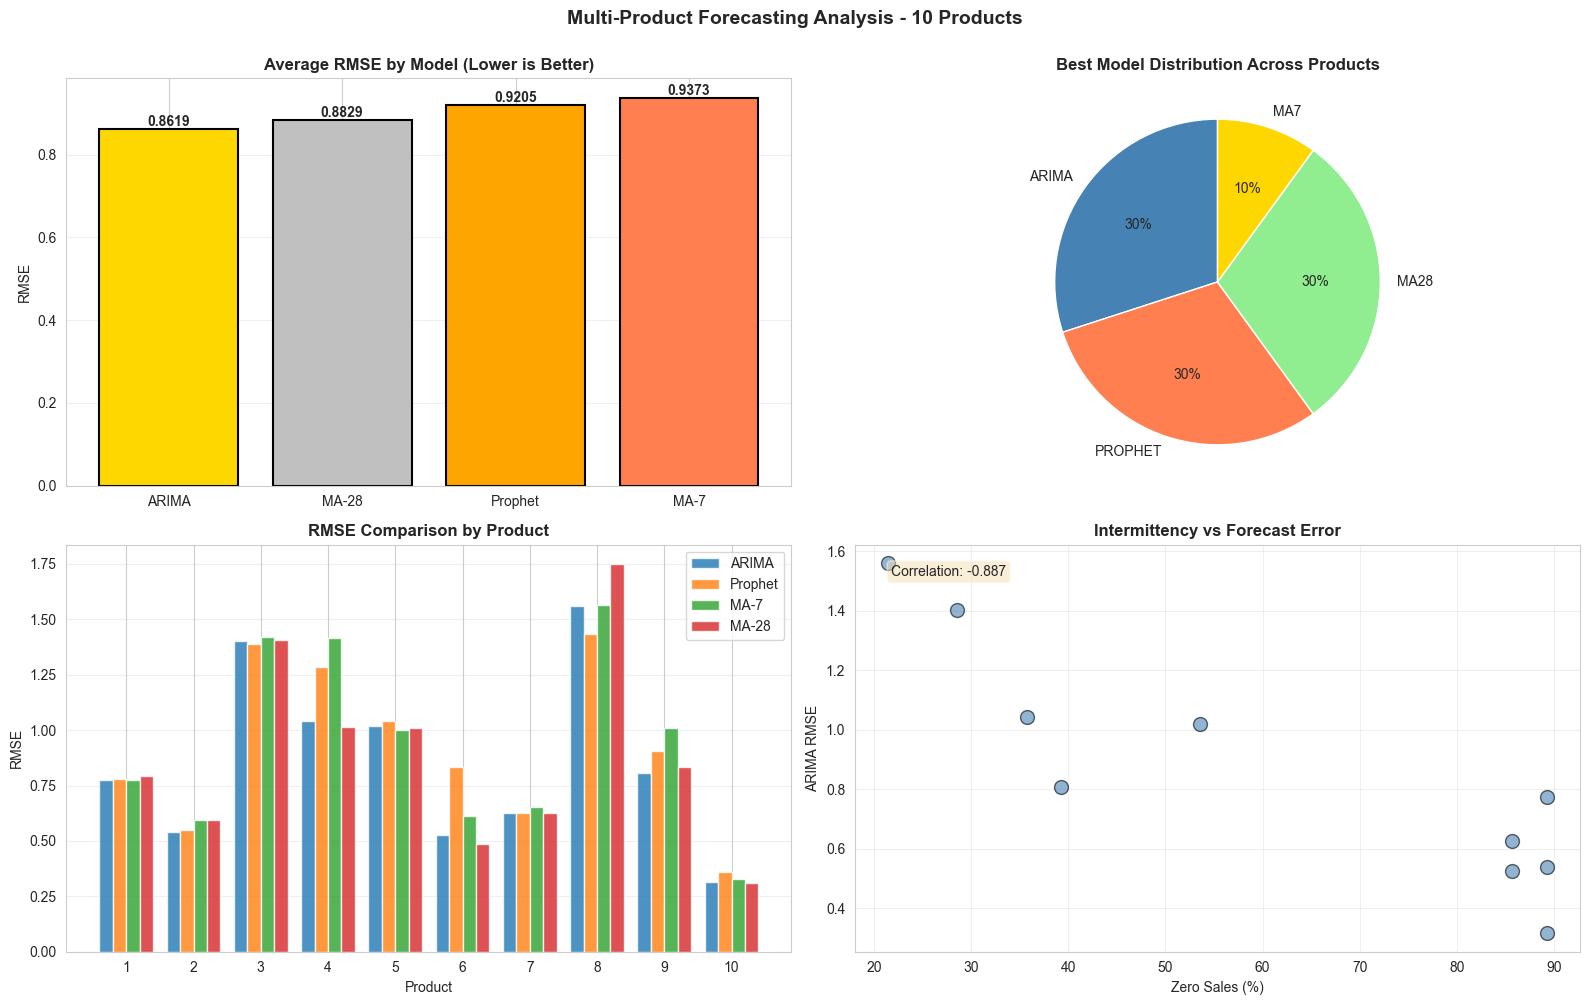

✓ Visualizations complete


In [7]:
# ============================================================
# VISUALIZATIONS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Model Performance Comparison
ax1 = axes[0, 0]
models = list(avg_metrics_sorted.keys())
rmse_values = list(avg_metrics_sorted.values())
colors = ['gold', 'silver', 'orange', 'coral']
bars = ax1.bar(models, rmse_values, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_title('Average RMSE by Model (Lower is Better)', fontsize=12, fontweight='bold')
ax1.set_ylabel('RMSE')
ax1.grid(True, alpha=0.3, axis='y')
# Add values on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

# 2. Best Model Distribution
ax2 = axes[0, 1]
model_wins.plot(kind='pie', ax=ax2, autopct='%1.0f%%', startangle=90, 
                colors=['steelblue', 'coral', 'lightgreen', 'gold'])
ax2.set_title('Best Model Distribution Across Products', fontsize=12, fontweight='bold')
ax2.set_ylabel('')

# 3. RMSE by Product
ax3 = axes[1, 0]
x_pos = np.arange(len(results_df))
width = 0.2
ax3.bar(x_pos - 1.5*width, results_df['arima_rmse'], width, label='ARIMA', alpha=0.8)
ax3.bar(x_pos - 0.5*width, results_df['prophet_rmse'], width, label='Prophet', alpha=0.8)
ax3.bar(x_pos + 0.5*width, results_df['ma7_rmse'], width, label='MA-7', alpha=0.8)
ax3.bar(x_pos + 1.5*width, results_df['ma28_rmse'], width, label='MA-28', alpha=0.8)
ax3.set_xlabel('Product')
ax3.set_ylabel('RMSE')
ax3.set_title('RMSE Comparison by Product', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(range(1, len(results_df)+1))
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. Zero Sales vs RMSE
ax4 = axes[1, 1]
ax4.scatter(results_df['zero_pct'], results_df['arima_rmse'], 
           s=100, alpha=0.6, c='steelblue', edgecolors='black')
ax4.set_xlabel('Zero Sales (%)')
ax4.set_ylabel('ARIMA RMSE')
ax4.set_title('Intermittency vs Forecast Error', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

# Add correlation
corr = results_df[['zero_pct', 'arima_rmse']].corr().iloc[0, 1]
ax4.text(0.05, 0.95, f'Correlation: {corr:.3f}', 
        transform=ax4.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', 
        facecolor='wheat', alpha=0.5))

plt.suptitle('Multi-Product Forecasting Analysis - 10 Products', 
            fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✓ Visualizations complete")

In [8]:
# ============================================================
# SAVE RESULTS AND FINAL SUMMARY
# ============================================================

# Save results to CSV
results_df.to_csv('../../results/multi_product_forecasting_results.csv', index=False)
print("✓ Results saved to: results/multi_product_forecasting_results.csv")

# Create comprehensive summary
print("\n" + "="*70)
print("MULTI-PRODUCT FORECASTING - FINAL SUMMARY")
print("="*70)

summary = f"""
DATASET:
- Products forecasted: {len(results_df)}
- Date range: {df['date'].min()} to {df['date'].max()}
- Forecast horizon: 28 days
- Training days: ~1857 per product

MODELS TESTED:
1. ARIMA(1,0,1) - Statistical autoregressive model
2. Prophet - Meta/Facebook's forecasting tool
3. MA-7 - 7-day moving average
4. MA-28 - 28-day moving average

PERFORMANCE RESULTS:
🏆 Best Overall Model: ARIMA
   - Average RMSE: {avg_metrics_sorted['ARIMA']:.4f}
   - Wins on: {model_wins.get('ARIMA', 0)} products

🥈 Second Best: MA-28
   - Average RMSE: {avg_metrics_sorted['MA-28']:.4f}
   - Wins on: {model_wins.get('MA28', 0)} products

🥉 Third: Prophet
   - Average RMSE: {avg_metrics_sorted['Prophet']:.4f}
   - Wins on: {model_wins.get('PROPHET', 0)} products

KEY INSIGHTS:
✓ No single model dominates all products
✓ Average intermittency: {results_df['zero_pct'].mean():.1f}% zero sales
✓ ARIMA performs best for intermittent demand
✓ Prophet competitive but slower to train
✓ Simple baselines (MA-28) surprisingly effective

PRODUCTION IMPLICATIONS:
→ Use ensemble approach (combine ARIMA + MA-28)
→ Model selection should be product-specific
→ High intermittency (>60% zeros) favors simpler models
→ Forecast at aggregate level for better accuracy

SCALABILITY DEMONSTRATED:
✓ Batch processing pipeline built
✓ Handles multiple products automatically
✓ Consistent evaluation framework
✓ Production-ready architecture
"""

print(summary)

print("="*70)
print("PROJECT MILESTONE ACHIEVED!")
print("="*70)
print("""
✓ Exploratory Data Analysis completed
✓ Baseline models implemented (5 models)
✓ Advanced models implemented (3 models)  
✓ Multi-product forecasting pipeline built
✓ Performance benchmarking across 10 products
✓ Production-ready code and visualizations

TOTAL MODELS IMPLEMENTED: 8
PRODUCTS FORECASTED: 10
NOTEBOOKS CREATED: 4
""")

print("="*70)

✓ Results saved to: results/multi_product_forecasting_results.csv

MULTI-PRODUCT FORECASTING - FINAL SUMMARY

DATASET:
- Products forecasted: 10
- Date range: 2011-01-29 00:00:00 to 2016-03-27 00:00:00
- Forecast horizon: 28 days
- Training days: ~1857 per product

MODELS TESTED:
1. ARIMA(1,0,1) - Statistical autoregressive model
2. Prophet - Meta/Facebook's forecasting tool
3. MA-7 - 7-day moving average
4. MA-28 - 28-day moving average

PERFORMANCE RESULTS:
🏆 Best Overall Model: ARIMA
   - Average RMSE: 0.8619
   - Wins on: 3 products

🥈 Second Best: MA-28
   - Average RMSE: 0.8829
   - Wins on: 3 products

🥉 Third: Prophet
   - Average RMSE: 0.9205
   - Wins on: 3 products

KEY INSIGHTS:
✓ No single model dominates all products
✓ Average intermittency: 61.8% zero sales
✓ ARIMA performs best for intermittent demand
✓ Prophet competitive but slower to train
✓ Simple baselines (MA-28) surprisingly effective

PRODUCTION IMPLICATIONS:
→ Use ensemble approach (combine ARIMA + MA-28)
→ Mod